In [130]:
#!pip -q install kagglehub albumentations opencv-python-headless pandas tqdm
# !pip -q install kagglehub matplotlib pillow scikit-learn

In [131]:
# -------------------------
# Imports
# -------------------------
import os
import csv
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision import transforms as T
from tqdm.auto import tqdm


In [132]:
# -------------------------
# Mount Google Drive
# -------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [133]:
CFG = {
    "SEED": 42,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    # Dataset
    "KAGGLE_DATASET": "arischii05/cleaned-foodseg103",
    "EXPECTED_SUBDIRS": [
        "foodseg103_rebalanced/foodseg103_rebalanced",
        "cleaned-foodseg103",
        "foodseg103"
    ],

    # Save
    "SAVE_DIR": "/content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit",
    "LAST_CKPT": "bisenet_xception39_like_last.pth",
    "BEST_CKPT": "bisenet_xception39_like_best.pth",
    "METRICS_JSON": "metrics_history_overfit8.json",
    "METRICS_CSV": "metrics_history_overfit8.csv",
    "BEST_METRICS_JSON": "best_metrics_overfit8.json",

    # Train
    "EPOCHS": 150,
    "BATCH_SIZE": 8,
    "NUM_WORKERS": 0,              # avoid child process issues on Colab
    "VAL_RATIO": 0.1,
    "CROP_SIZE": 512,
    "SCALES": [0.75, 1.0, 1.5, 1.75, 2.0],
    "LR_START": 2.5e-2,
    "MOMENTUM": 0.9,
    "WEIGHT_DECAY": 1e-4,
    "POWER": 0.9,
    "AUX_WEIGHT": 1.0,
    "IGNORE_INDEX": 255,
    "AMP": True,
    "RESUME": True,

    # Overfit mode
    "OVERFIT_MODE": True,
    "OVERFIT_SAMPLES": 8,

    # Debug / smoke-test fallback (used only when OVERFIT_MODE=False)
    "MAX_TRAIN_SAMPLES": None,
    "MAX_VAL_SAMPLES": 64,
    "NUM_VIS": 4,
}

os.makedirs(CFG["SAVE_DIR"], exist_ok=True)

LAST_PATH = os.path.join(CFG["SAVE_DIR"], CFG["LAST_CKPT"])
BEST_PATH = os.path.join(CFG["SAVE_DIR"], CFG["BEST_CKPT"])
METRICS_JSON_PATH = os.path.join(CFG["SAVE_DIR"], CFG["METRICS_JSON"])
METRICS_CSV_PATH = os.path.join(CFG["SAVE_DIR"], CFG["METRICS_CSV"])
BEST_METRICS_PATH = os.path.join(CFG["SAVE_DIR"], CFG["BEST_METRICS_JSON"])

In [134]:
random.seed(CFG["SEED"])
np.random.seed(CFG["SEED"])
torch.manual_seed(CFG["SEED"])
torch.cuda.manual_seed_all(CFG["SEED"])

In [135]:
import kagglehub

print("=" * 80)
print("Downloading dataset from KaggleHub:", CFG["KAGGLE_DATASET"])
dataset_root = Path(kagglehub.dataset_download(CFG["KAGGLE_DATASET"]))
print("KaggleHub root:", dataset_root)

Using Colab cache for faster access to the 'cleaned-foodseg103' dataset.
KaggleHub root: /kaggle/input/cleaned-foodseg103


In [136]:
candidates = []

for name in CFG["EXPECTED_SUBDIRS"]:
    p = dataset_root / name
    if p.exists():
        candidates.append(p)

if not candidates:
    for p in dataset_root.rglob("*"):
        if p.is_dir() and p.name in CFG["EXPECTED_SUBDIRS"]:
            candidates.append(p)

if not candidates:
    for p in dataset_root.rglob("*"):
        if p.is_dir() and (p / "train" / "img").exists() and (p / "train" / "mask").exists():
            candidates.append(p)

if len(candidates) == 0:
    raise FileNotFoundError(f"Cannot resolve data root from {dataset_root}")

candidates = sorted(
    candidates,
    key=lambda x: (0 if "rebalanced" in x.name.lower() else 1, len(str(x)))
)

DATA_ROOT = candidates[0]

print("Resolved DATA_ROOT:", DATA_ROOT)
print("All candidates:")
for c in candidates[:10]:
    print(" -", c)

Resolved DATA_ROOT: /kaggle/input/cleaned-foodseg103/foodseg103_rebalanced/foodseg103_rebalanced
All candidates:
 - /kaggle/input/cleaned-foodseg103/foodseg103_rebalanced/foodseg103_rebalanced
 - /kaggle/input/cleaned-foodseg103/cleaned-foodseg103


Read class mapping / infer num_classes

In [137]:
NUM_CLASSES = 77
ID_TO_CLASS = {}

mapping_path = DATA_ROOT / "class_mapping.json"
if mapping_path.exists():
    with open(mapping_path, "r", encoding="utf-8") as f:
        mapping = json.load(f)

    NUM_CLASSES = int(mapping.get("num_classes", NUM_CLASSES))
    raw_id_to_class = mapping.get("id_to_class", {})
    ID_TO_CLASS = {int(k): v for k, v in raw_id_to_class.items()}
    print("Loaded class_mapping.json")
else:
    print("WARNING: class_mapping.json not found, fallback NUM_CLASSES =", NUM_CLASSES)

BACKGROUND_ID = 0

Loaded class_mapping.json


In [138]:
print("=" * 80)
print("CONFIG SUMMARY")
for k, v in CFG.items():
    print(f"{k}: {v}")
print("NUM_CLASSES:", NUM_CLASSES)
print("BACKGROUND_ID:", BACKGROUND_ID)
print("DEVICE:", CFG["DEVICE"])
print("SAVE_DIR:", CFG["SAVE_DIR"])
print("=" * 80)

CONFIG SUMMARY
SEED: 42
DEVICE: cuda
KAGGLE_DATASET: arischii05/cleaned-foodseg103
EXPECTED_SUBDIRS: ['foodseg103_rebalanced/foodseg103_rebalanced', 'cleaned-foodseg103', 'foodseg103']
SAVE_DIR: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit
LAST_CKPT: bisenet_xception39_like_last.pth
BEST_CKPT: bisenet_xception39_like_best.pth
METRICS_JSON: metrics_history_overfit8.json
METRICS_CSV: metrics_history_overfit8.csv
BEST_METRICS_JSON: best_metrics_overfit8.json
EPOCHS: 150
BATCH_SIZE: 8
NUM_WORKERS: 0
VAL_RATIO: 0.1
CROP_SIZE: 512
SCALES: [0.75, 1.0, 1.5, 1.75, 2.0]
LR_START: 0.025
MOMENTUM: 0.9
WEIGHT_DECAY: 0.0001
POWER: 0.9
AUX_WEIGHT: 1.0
IGNORE_INDEX: 255
AMP: True
RESUME: True
OVERFIT_MODE: True
OVERFIT_SAMPLES: 8
MAX_TRAIN_SAMPLES: 32
MAX_VAL_SAMPLES: 32
NUM_VIS: 4
NUM_CLASSES: 76
BACKGROUND_ID: 0
DEVICE: cuda
SAVE_DIR: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit


In [139]:
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def find_image_path(img_dir, stem):
    for ext in IMG_EXTS:
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None

img_dir = DATA_ROOT / "train" / "img"
mask_dir = DATA_ROOT / "train" / "mask"

assert img_dir.exists(), f"Missing img_dir: {img_dir}"
assert mask_dir.exists(), f"Missing mask_dir: {mask_dir}"

stems = []
for p in img_dir.iterdir():
    if p.is_file() and p.suffix.lower() in IMG_EXTS:
        stem = p.stem
        if (mask_dir / f"{stem}.png").exists():
            stems.append(stem)

stems = sorted(stems)

train_all = []
for stem in stems:
    img_path = find_image_path(img_dir, stem)
    mask_path = mask_dir / f"{stem}.png"
    if img_path is not None and mask_path.exists():
        train_all.append((str(img_path), str(mask_path), stem))

print(f"Found train samples: {len(train_all)}")

Found train samples: 3981


Optional trim + split train/val

In [140]:
if CFG["OVERFIT_MODE"]:
    overfit_k = min(CFG["OVERFIT_SAMPLES"], len(train_all))
    if overfit_k <= 0:
        raise ValueError("No samples available for overfit mode.")

    rng = random.Random(CFG["SEED"])
    chosen_idx = rng.sample(range(len(train_all)), k=overfit_k)
    overfit_samples = [train_all[i] for i in chosen_idx]

    train_samples = overfit_samples
    val_samples = overfit_samples

    print(f"OVERFIT MODE ON -> using {len(overfit_samples)} samples for both train and val")
    print("Overfit sample stems (first 8):", [s[2] for s in overfit_samples[:8]])
else:
    if CFG["MAX_TRAIN_SAMPLES"] is not None:
        train_all = train_all[:CFG["MAX_TRAIN_SAMPLES"]]
        print(f"Trimmed train_all to: {len(train_all)}")

    train_samples, val_samples = train_test_split(
        train_all,
        test_size=CFG["VAL_RATIO"],
        random_state=CFG["SEED"],
        shuffle=True
    )

    if CFG["MAX_VAL_SAMPLES"] is not None:
        val_samples = val_samples[:CFG["MAX_VAL_SAMPLES"]]

print(f"Split -> train: {len(train_samples)} | val: {len(val_samples)}")

OVERFIT MODE ON -> using 8 samples for both train and val
Overfit sample stems (first 8): ['00002623', '00000458', '00000103', '00003041', '00001128', '00001005', '00000916', '00000573']
Split -> train: 8 | val: 8


Normalization constants

In [141]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

TRANSFORM

In [142]:
class TrainTransform:
    def __call__(self, image, mask):
        scale = random.choice(CFG["SCALES"])
        w, h = image.size
        nw, nh = max(32, int(w * scale)), max(32, int(h * scale))

        image = image.resize((nw, nh), Image.BILINEAR)
        mask = mask.resize((nw, nh), Image.NEAREST)

        if random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        pad_h = max(0, CFG["CROP_SIZE"] - nh)
        pad_w = max(0, CFG["CROP_SIZE"] - nw)

        if pad_h > 0 or pad_w > 0:
            image = TF.pad(image, [0, 0, pad_w, pad_h], fill=0)
            mask = TF.pad(mask, [0, 0, pad_w, pad_h], fill=CFG["IGNORE_INDEX"])

        i, j, h, w = T.RandomCrop.get_params(
            image,
            output_size=(CFG["CROP_SIZE"], CFG["CROP_SIZE"])
        )

        image = TF.crop(image, i, j, h, w)
        mask = TF.crop(mask, i, j, h, w)

        image = TF.to_tensor(image)
        image = TF.normalize(image, IMAGENET_MEAN, IMAGENET_STD)

        mask = torch.from_numpy(np.array(mask, dtype=np.int64))
        invalid = (mask < 0) | (mask >= NUM_CLASSES)
        mask[invalid] = CFG["IGNORE_INDEX"]

        return image, mask

VALTRANSFORM

In [143]:
class ValTransform:
    def __call__(self, image, mask):
        image = image.resize((CFG["CROP_SIZE"], CFG["CROP_SIZE"]), Image.BILINEAR)
        mask = mask.resize((CFG["CROP_SIZE"], CFG["CROP_SIZE"]), Image.NEAREST)

        image = TF.to_tensor(image)
        image = TF.normalize(image, IMAGENET_MEAN, IMAGENET_STD)

        mask = torch.from_numpy(np.array(mask, dtype=np.int64))
        invalid = (mask < 0) | (mask >= NUM_CLASSES)
        mask[invalid] = CFG["IGNORE_INDEX"]

        return image, mask

In [144]:
class FoodSegDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, stem = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        image, mask = self.transform(image, mask)
        return image, mask, stem, img_path, mask_path

In [145]:
DataLoader

torch.utils.data.dataloader.DataLoader

In [146]:
train_loader = DataLoader(
    FoodSegDataset(train_samples, TrainTransform()),
    batch_size=CFG["BATCH_SIZE"],
    shuffle=True,
    num_workers=CFG["NUM_WORKERS"],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    FoodSegDataset(val_samples, ValTransform()),
    batch_size=max(1, CFG["BATCH_SIZE"] // 2),
    shuffle=False,
    num_workers=CFG["NUM_WORKERS"],
    pin_memory=True
)

CELL 17 — First batch debug

In [147]:
first_batch = next(iter(train_loader))
images_dbg, masks_dbg, stems_dbg, img_paths_dbg, mask_paths_dbg = first_batch

print("=" * 80)
print("FIRST BATCH DEBUG")
print("images shape:", tuple(images_dbg.shape))
print("masks shape :", tuple(masks_dbg.shape))
print("stems       :", list(stems_dbg[:4]))
print("img path    :", img_paths_dbg[0])
print("mask path   :", mask_paths_dbg[0])

uniq = torch.unique(masks_dbg[0])
uniq_show = uniq.cpu().tolist()[:50]
print("unique labels in first mask (first 50):", uniq_show)
print("min label:", int(masks_dbg.min()))
print("max label:", int(masks_dbg[masks_dbg != CFG["IGNORE_INDEX"]].max()))
print("=" * 80)

FIRST BATCH DEBUG
images shape: (8, 3, 512, 512)
masks shape : (8, 512, 512)
stems       : ['00002623', '00001005', '00000458', '00000916']
img path    : /kaggle/input/cleaned-foodseg103/foodseg103_rebalanced/foodseg103_rebalanced/train/img/00002623.jpg
mask path   : /kaggle/input/cleaned-foodseg103/foodseg103_rebalanced/foodseg103_rebalanced/train/mask/00002623.png
unique labels in first mask (first 50): [0, 16, 20, 56]
min label: 0
max label: 71


# MODEL

In [148]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, ks, stride, padding, bias=bias),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, dilation=1, bias=False):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride, padding, dilation,
            groups=in_channels, bias=bias
        )
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, 1, 1, bias=bias)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return x

class Block(nn.Module):
    def __init__(self, in_filters, out_filters, reps, strides=1, start_with_relu=True, grow_first=True):
        super().__init__()

        if out_filters != in_filters or strides != 1:
            self.skip = nn.Conv2d(in_filters, out_filters, 1, stride=strides, bias=False)
            self.skipbn = nn.BatchNorm2d(out_filters)
        else:
            self.skip = None

        self.relu = nn.ReLU(inplace=True)
        rep = []
        filters = in_filters

        if grow_first:
            rep.append(self.relu if start_with_relu else nn.Identity())
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1, bias=False))
            filters = out_filters

        for _ in range(reps - 1):
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(filters, filters, 3, stride=1, padding=1, bias=False))

        if not grow_first:
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1, bias=False))

        if strides != 1:
            rep.append(nn.MaxPool2d(3, strides, 1))

        self.rep = nn.Sequential(*rep)

    def forward(self, inp):
        x = self.rep(inp)
        if self.skip is not None:
            skip = self.skipbn(self.skip(inp))
        else:
            skip = inp
        x = x + skip
        return x


class Xception39(nn.Module):
    """
    Outputs:
      feat8  : /8
      feat16 : /16
      feat32 : /32
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(8, 16, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(16)

        self.block1 = Block(16, 32, reps=3, strides=2, start_with_relu=False, grow_first=True)
        self.block2 = Block(32, 64, reps=3, strides=2, start_with_relu=True, grow_first=True)
        self.block3 = Block(64, 128, reps=3, strides=2, start_with_relu=True, grow_first=True)

        self.out_channels = (32, 64, 128)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        feat8 = self.block1(x)
        feat16 = self.block2(feat8)
        feat32 = self.block3(feat16)
        return feat8, feat16, feat32

class AttentionRefinementModule(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBNReLU(in_ch, out_ch, ks=3, stride=1, padding=1)
        self.attn_conv = nn.Conv2d(out_ch, out_ch, kernel_size=1, bias=False)
        self.attn_bn = nn.BatchNorm2d(out_ch)
        self.attn_sigmoid = nn.Sigmoid()

    def forward(self, x):
        feat = self.conv(x)
        attn = F.adaptive_avg_pool2d(feat, output_size=1)
        attn = self.attn_conv(attn)
        attn = self.attn_bn(attn)
        attn = self.attn_sigmoid(attn)
        return feat * attn


class SpatialPath(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ConvBNReLU(3, 64, ks=7, stride=2, padding=3)
        self.conv2 = ConvBNReLU(64, 64, ks=3, stride=2, padding=1)
        self.conv3 = ConvBNReLU(64, 64, ks=3, stride=2, padding=1)
        self.conv_out = ConvBNReLU(64, 128, ks=1, stride=1, padding=0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv_out(x)
        return x


class ContextPath(nn.Module):
    def __init__(self, backbone=None):
        super().__init__()
        self.backbone = Xception39() if backbone is None else backbone
        c8, c16, c32 = self.backbone.out_channels

        self.arm16 = AttentionRefinementModule(c16, 128)
        self.arm32 = AttentionRefinementModule(c32, 128)

        self.global_context = ConvBNReLU(c32, 128, ks=1, stride=1, padding=0)

        self.refine16 = ConvBNReLU(128, 128, ks=3, stride=1, padding=1)
        self.refine32 = ConvBNReLU(128, 128, ks=3, stride=1, padding=1)

    def forward(self, x):
        feat8, feat16, feat32 = self.backbone(x)

        tail = F.adaptive_avg_pool2d(feat32, output_size=1)
        tail = self.global_context(tail)
        tail = F.interpolate(tail, size=feat32.shape[-2:], mode="bilinear", align_corners=False)

        feat32_arm = self.arm32(feat32)
        feat32_sum = feat32_arm + tail
        feat32_up = F.interpolate(
            self.refine32(feat32_sum),
            size=feat16.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        feat16_arm = self.arm16(feat16)
        feat16_sum = feat16_arm + feat32_up
        feat16_up = F.interpolate(
            self.refine16(feat16_sum),
            size=feat8.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        return feat16_up, feat16_sum, feat32_sum



class FeatureFusionModule(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.convblk = ConvBNReLU(in_ch, out_ch, ks=1, stride=1, padding=0)
        self.attn1 = nn.Conv2d(out_ch, out_ch // 4, kernel_size=1, bias=False)
        self.attn_relu = nn.ReLU(inplace=True)
        self.attn2 = nn.Conv2d(out_ch // 4, out_ch, kernel_size=1, bias=False)
        self.attn_sigmoid = nn.Sigmoid()

    def forward(self, fsp, fcp):
        feat = torch.cat([fsp, fcp], dim=1)
        feat = self.convblk(feat)

        attn = F.adaptive_avg_pool2d(feat, output_size=1)
        attn = self.attn1(attn)
        attn = self.attn_relu(attn)
        attn = self.attn2(attn)
        attn = self.attn_sigmoid(attn)

        return feat + feat * attn


class SegHead(nn.Module):
    def __init__(self, in_ch, mid_ch, n_classes):
        super().__init__()
        self.conv = ConvBNReLU(in_ch, mid_ch, ks=3, stride=1, padding=1)
        self.drop = nn.Dropout2d(0.1)
        self.cls = nn.Conv2d(mid_ch, n_classes, kernel_size=1)

    def forward(self, x, out_size=None):
        x = self.conv(x)
        x = self.drop(x)
        x = self.cls(x)
        if out_size is not None:
            x = F.interpolate(x, size=out_size, mode="bilinear", align_corners=False)
        return x

BISENET

In [149]:
class BiSeNetV1(nn.Module):
    def __init__(self, n_classes=19, backbone=None):
        super().__init__()
        self.spatial_path = SpatialPath()
        self.context_path = ContextPath(backbone=backbone)
        self.ffm = FeatureFusionModule(128 + 128, 256)

        self.head = SegHead(256, 256, n_classes)
        self.aux_head16 = SegHead(128, 64, n_classes)
        self.aux_head32 = SegHead(128, 64, n_classes)

    def forward(self, x):
        out_hw = x.shape[-2:]

        feat_sp = self.spatial_path(x)
        feat_cp8, feat_cp16, feat_cp32 = self.context_path(x)
        feat_fuse = self.ffm(feat_sp, feat_cp8)

        logits = self.head(feat_fuse, out_size=out_hw)
        aux16 = self.aux_head16(feat_cp16, out_size=out_hw)
        aux32 = self.aux_head32(feat_cp32, out_size=out_hw)

        if self.training:
            return logits, aux16, aux32
        return logits

build, optimizer, loss, scaler

In [150]:
model = BiSeNetV1(n_classes=NUM_CLASSES).to(CFG["DEVICE"])

criterion = nn.CrossEntropyLoss(ignore_index=CFG["IGNORE_INDEX"])

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=CFG["LR_START"],
    momentum=CFG["MOMENTUM"],
    weight_decay=CFG["WEIGHT_DECAY"]
)

scaler = torch.cuda.amp.GradScaler(enabled=CFG["AMP"])

/tmp/ipykernel_11572/3913418837.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CFG["AMP"])


summary, run

In [151]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 80)
print("MODEL SUMMARY")
print(model)
print("Total params    :", f"{total_params:,}")
print("Trainable params:", f"{trainable_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, 3, CFG["CROP_SIZE"], CFG["CROP_SIZE"]).to(CFG["DEVICE"])
    model.train()
    out_main, out_aux16, out_aux32 = model(dummy)
    print("Dry run shapes:")
    print("  logits :", tuple(out_main.shape))
    print("  aux16  :", tuple(out_aux16.shape))
    print("  aux32  :", tuple(out_aux32.shape))
print("=" * 80)

MODEL SUMMARY
BiSeNetV1(
  (spatial_path): SpatialPath(
    (conv1): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (conv2): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (conv3): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (conv_out): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1,

resume checkpoint state

In [152]:
start_epoch = 0
best_miou = 0.0
global_iter = 0

if CFG["RESUME"] and os.path.isfile(LAST_PATH):
    ckpt = torch.load(LAST_PATH, map_location=CFG["DEVICE"])
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scaler.load_state_dict(ckpt["scaler"])
    start_epoch = ckpt["epoch"] + 1
    best_miou = ckpt.get("best_miou", 0.0)
    global_iter = ckpt.get("global_iter", 0)

    print(f"Resumed from checkpoint: {LAST_PATH}")
    print(f"start_epoch={start_epoch}, best_miou={best_miou:.4f}, global_iter={global_iter}")
else:
    print("No checkpoint resumed. Training from scratch.")

Resumed from checkpoint: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/bisenet_xception39_like_last.pth
start_epoch=100, best_miou=0.1324, global_iter=100


LR schedule

In [153]:
iters_per_epoch = len(train_loader)
max_iter = max(1, CFG["EPOCHS"] * iters_per_epoch)

In [154]:
def poly_lr(base_lr, cur_iter, max_iter, power=0.9):
    return base_lr * (1 - float(cur_iter) / float(max_iter)) ** power

In [155]:
def save_ckpt(path, epoch, best, scores=None):
    """Save full training state for resume and analysis.

    Args:
        path: Destination checkpoint path on disk.
        epoch: Current epoch index.
        best: Best mIoU value so far.
        scores: Optional validation metrics dictionary.

    Returns:
        None.

    Raises:
        OSError: If checkpoint cannot be written.
    """
    torch.save({
        "epoch": epoch,
        "global_iter": global_iter,
        "best_miou": best,
        "scores": scores,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "cfg": CFG,
        "num_classes": NUM_CLASSES,
        "data_root": str(DATA_ROOT),
    }, path)


def save_metrics_files(history):
    """Persist metric history to Drive as JSON and CSV.

    Args:
        history: List of per-epoch metric dictionaries.

    Returns:
        None.

    Raises:
        OSError: If output files cannot be written.
    """
    with open(METRICS_JSON_PATH, "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    if not history:
        with open(METRICS_CSV_PATH, "w", newline="", encoding="utf-8") as f:
            f.write("")
        return

    fieldnames = list(history[0].keys())
    with open(METRICS_CSV_PATH, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(history)

# metrics

In [156]:
@torch.no_grad()
def fast_hist(pred, target, num_classes, ignore_index=255):
    mask = target != ignore_index
    pred = pred[mask]
    target = target[mask]
    k = (target >= 0) & (target < num_classes)
    inds = num_classes * target[k].to(torch.int64) + pred[k]
    hist = torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes)
    return hist

In [157]:
@torch.no_grad()
def compute_scores(hist):
    hist = hist.float()
    aAcc = torch.diag(hist).sum() / hist.sum().clamp_min(1.0)
    acc_cls = torch.diag(hist) / hist.sum(dim=1).clamp_min(1.0)
    mAcc = torch.nanmean(acc_cls)
    iu = torch.diag(hist) / (hist.sum(dim=1) + hist.sum(dim=0) - torch.diag(hist)).clamp_min(1.0)
    mIoU = torch.nanmean(iu)
    return {
        "aAcc": aAcc.item(),
        "mAcc": mAcc.item(),
        "mIoU": mIoU.item(),
    }

# visualize

In [158]:
def denorm_image(t):
    x = t.detach().cpu().clone()
    for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        x[c] = x[c] * s + m
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()

def make_palette(n, seed=123):
    rng = np.random.default_rng(seed)
    palette = rng.integers(0, 255, size=(n, 3), dtype=np.uint8)
    palette[0] = np.array([0, 0, 0], dtype=np.uint8)
    return palette

PALETTE = make_palette(NUM_CLASSES)

def colorize_mask(mask_np):
    mask_np = np.clip(mask_np, 0, NUM_CLASSES - 1)
    return PALETTE[mask_np]

def overlay_mask(image_np, mask_np, alpha=0.45):
    color = colorize_mask(mask_np)
    fg = (mask_np != BACKGROUND_ID)[..., None]
    over = np.where(fg, (1 - alpha) * image_np * 255 + alpha * color, image_np * 255)
    over = np.clip(over, 0, 255).astype(np.uint8)
    return over

# Visualize predictions

In [159]:
@torch.no_grad()
def visualize_predictions(model, loader, num_vis=4):
    model.eval()

    batch = next(iter(loader))
    images, masks, stems, _, _ = batch
    images = images.to(CFG["DEVICE"])

    logits = model(images)
    preds = logits.argmax(1).cpu().numpy()

    images = images.cpu()
    masks = masks.cpu().numpy()

    n = min(num_vis, len(images))
    plt.figure(figsize=(16, 4 * n))

    for i in range(n):
        img = denorm_image(images[i])

        gt = masks[i].copy()
        gt[gt == CFG["IGNORE_INDEX"]] = 0

        pred = preds[i]

        over_gt = overlay_mask(img, gt)
        over_pred = overlay_mask(img, pred)

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(img)
        plt.title(f"Image\n{stems[i]}")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(over_gt)
        plt.title(f"GT overlay\nuniq={len(np.unique(gt))}")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(over_pred)
        plt.title(f"Pred overlay\nuniq={len(np.unique(pred))}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# TRAINING

In [160]:
def train_one_epoch(epoch):
    global global_iter

    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Train {epoch:03d}", leave=False)

    for step, (images, masks, stems, _, _) in enumerate(pbar):
        images = images.to(CFG["DEVICE"], non_blocking=True)
        masks = masks.to(CFG["DEVICE"], non_blocking=True)

        lr = poly_lr(CFG["LR_START"], global_iter, max_iter, CFG["POWER"])
        for pg in optimizer.param_groups:
            pg["lr"] = lr

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=CFG["AMP"]):
            logits, aux16, aux32 = model(images)
            loss_main = criterion(logits, masks)
            loss_aux16 = criterion(aux16, masks)
            loss_aux32 = criterion(aux32, masks)
            loss = loss_main + CFG["AUX_WEIGHT"] * (loss_aux16 + loss_aux32)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        global_iter += 1

        if step == 0:
            print("-" * 80)
            print(f"[Epoch {epoch:03d} | step 0 debug]")
            print("images:", tuple(images.shape))
            print("masks :", tuple(masks.shape))
            print("logits:", tuple(logits.shape))
            print("aux16 :", tuple(aux16.shape))
            print("aux32 :", tuple(aux32.shape))
            print("loss_main :", float(loss_main.item()))
            print("loss_aux16:", float(loss_aux16.item()))
            print("loss_aux32:", float(loss_aux32.item()))
            print("lr:", lr)
            print("batch stems (first 4):", list(stems[:4]))
            print("-" * 80)

        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.6f}")

    return running_loss / max(1, len(train_loader))

# validate

In [161]:
@torch.no_grad()
def validate(epoch):
    model.eval()

    hist = torch.zeros((NUM_CLASSES, NUM_CLASSES), device=CFG["DEVICE"])
    running_loss = 0.0

    pbar = tqdm(val_loader, desc=f"Val   {epoch:03d}", leave=False)

    for images, masks, stems, _, _ in pbar:
        images = images.to(CFG["DEVICE"], non_blocking=True)
        masks = masks.to(CFG["DEVICE"], non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)
        running_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        hist += fast_hist(preds, masks, NUM_CLASSES, CFG["IGNORE_INDEX"])

    scores = compute_scores(hist)
    return running_loss / max(1, len(val_loader)), scores

# run

In [162]:
print("=" * 80)
print("START TRAINING")
print("=" * 80)

metrics_history = []
if CFG["RESUME"] and os.path.isfile(METRICS_JSON_PATH):
    try:
        with open(METRICS_JSON_PATH, "r", encoding="utf-8") as f:
            metrics_history = json.load(f)
        print(f"Loaded existing metrics history: {METRICS_JSON_PATH}")
    except Exception as e:
        print(f"Could not load previous metrics history, starting fresh. Reason: {e}")

for epoch in range(start_epoch, CFG["EPOCHS"]):
    train_loss = train_one_epoch(epoch)
    val_loss, scores = validate(epoch)

    is_best = scores["mIoU"] > best_miou
    if is_best:
        best_miou = scores["mIoU"]

    epoch_metrics = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "mIoU": float(scores["mIoU"]),
        "mAcc": float(scores["mAcc"]),
        "aAcc": float(scores["aAcc"]),
        "best_mIoU": float(best_miou),
        "global_iter": int(global_iter),
        "is_best": bool(is_best),
    }
    metrics_history.append(epoch_metrics)
    save_metrics_files(metrics_history)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"mIoU={scores['mIoU']:.4f} | "
        f"mAcc={scores['mAcc']:.4f} | "
        f"aAcc={scores['aAcc']:.4f} | "
        f"best={best_miou:.4f}"
    )

    save_ckpt(LAST_PATH, epoch, best_miou, scores=scores)

    if is_best:
        save_ckpt(BEST_PATH, epoch, best_miou, scores=scores)
        with open(BEST_METRICS_PATH, "w", encoding="utf-8") as f:
            json.dump(epoch_metrics, f, indent=2)
        print(f"Saved BEST -> {BEST_PATH}")
        print(f"Saved BEST METRICS -> {BEST_METRICS_PATH}")

print("=" * 80)
print("TRAIN DONE")
print("LAST CKPT:", LAST_PATH)
print("BEST CKPT:", BEST_PATH)
print("METRICS JSON:", METRICS_JSON_PATH)
print("METRICS CSV:", METRICS_CSV_PATH)
print("BEST METRICS:", BEST_METRICS_PATH)
print("=" * 80)

START TRAINING
Loaded existing metrics history: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/metrics_history_overfit8.json


Train 100:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_11572/2423351255.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG["AMP"]):


--------------------------------------------------------------------------------
[Epoch 100 | step 0 debug]
images: (8, 3, 512, 512)
masks : (8, 512, 512)
logits: (8, 76, 512, 512)
aux16 : (8, 76, 512, 512)
aux32 : (8, 76, 512, 512)
loss_main : 0.5312308073043823
loss_aux16: 1.0162171125411987
loss_aux32: 1.1217056512832642
lr: 0.009301026450282537
batch stems (first 4): ['00002623', '00000573', '00003041', '00000458']
--------------------------------------------------------------------------------


Val   100:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 148 | train_loss=2.1060 | val_loss=0.3450 | mIoU=0.1523 | mAcc=0.1719 | aAcc=0.8935 | best=0.1523
Saved BEST -> /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/bisenet_xception39_like_best.pth
Saved BEST METRICS -> /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/best_metrics_overfit8.json


Train 149:   0%|          | 0/1 [00:00<?, ?it/s]

--------------------------------------------------------------------------------
[Epoch 149 | step 0 debug]
images: (8, 3, 512, 512)
masks : (8, 512, 512)
logits: (8, 76, 512, 512)
aux16 : (8, 76, 512, 512)
aux32 : (8, 76, 512, 512)
loss_main : 0.33667072653770447
loss_aux16: 0.6340928673744202
loss_aux32: 0.6719672679901123
lr: 0.00027507927783674635
batch stems (first 4): ['00000573', '00001005', '00000103', '00000458']
--------------------------------------------------------------------------------


Val   149:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 149 | train_loss=1.6427 | val_loss=0.3444 | mIoU=0.1514 | mAcc=0.1718 | aAcc=0.8926 | best=0.1523
TRAIN DONE
LAST CKPT: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/bisenet_xception39_like_last.pth
BEST CKPT: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/bisenet_xception39_like_best.pth
METRICS JSON: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/metrics_history_overfit8.json
METRICS CSV: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/metrics_history_overfit8.csv
BEST METRICS: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/best_metrics_overfit8.json


Visualizing validation predictions...


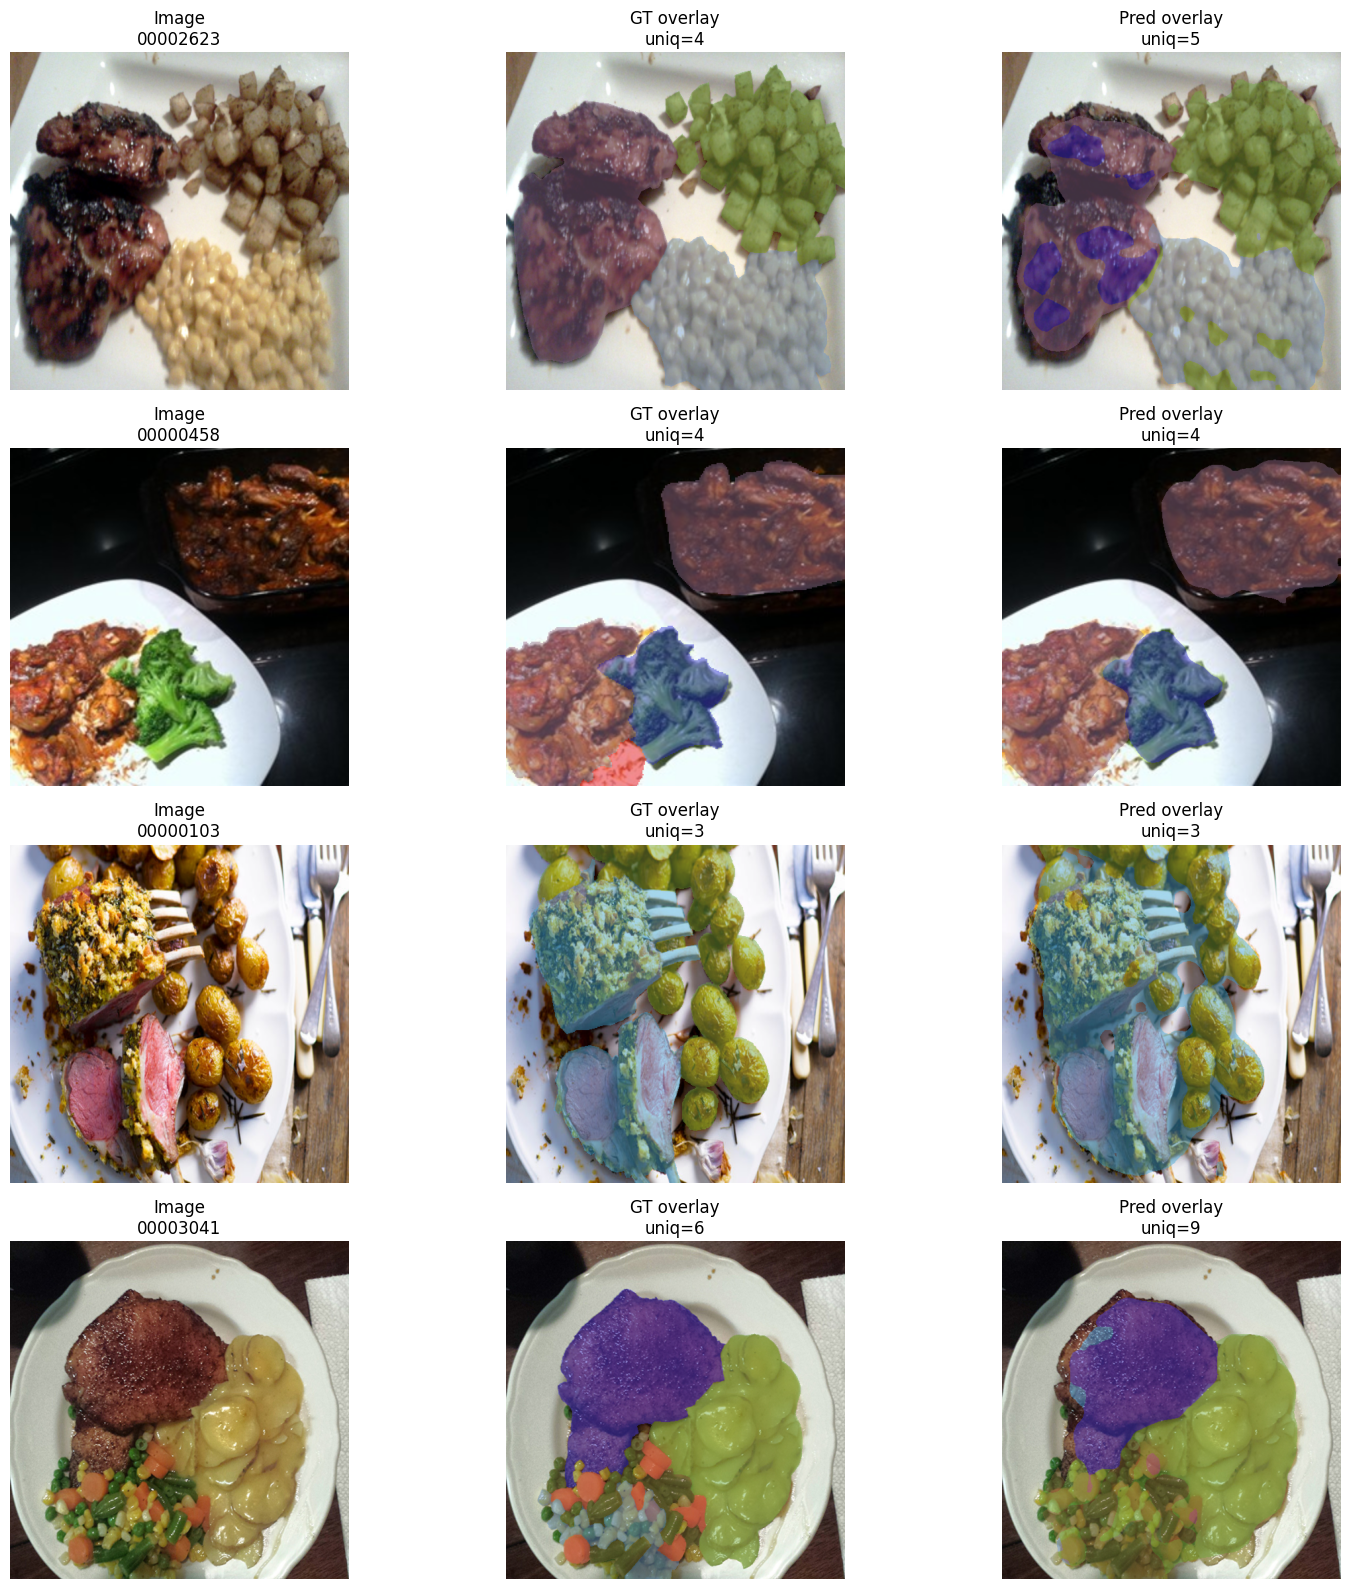

All done.


In [163]:
print("Visualizing validation predictions...")
visualize_predictions(model, val_loader, num_vis=CFG["NUM_VIS"])
print("All done.")

In [164]:
# =========================================================
# CELL NEW — Recompute metrics: average only classes present in each image
# Không sửa code cũ, chỉ chạy thêm cell này sau khi đã có model + val_loader
# =========================================================

import numpy as np
import torch
from tqdm.auto import tqdm

@torch.no_grad()
def recompute_present_metrics(model, loader, num_classes, ignore_index=255, background_id=0, device=None):
    """
    Recompute segmentation metrics with image-wise 'present-class only' averaging.

    Metric definitions:
    - aAcc:
        Global pixel accuracy over all valid pixels.
    - mIoU_present:
        For each image, compute IoU only on classes present in that image's GT.
        Then average across images.
    - mIoU_fg_present:
        Same as above, but exclude background_id.
    - mAcc_present:
        For each image, compute per-class accuracy only on classes present in GT.
        Then average across images.
    - mAcc_fg_present:
        Same as above, but exclude background_id.

    Also returns:
    - per_class_iou_present_dataset:
        For each class c, average IoU(c) only over images where class c appears in GT.
    """

    if device is None:
        device = CFG["DEVICE"]

    model.eval()

    total_correct = 0
    total_labeled = 0

    image_miou_present = []
    image_miou_fg_present = []
    image_macc_present = []
    image_macc_fg_present = []

    # per-class aggregation only on images where class is present in GT
    per_class_iou_sum = np.zeros(num_classes, dtype=np.float64)
    per_class_iou_count = np.zeros(num_classes, dtype=np.int64)

    per_class_acc_sum = np.zeros(num_classes, dtype=np.float64)
    per_class_acc_count = np.zeros(num_classes, dtype=np.int64)

    for images, masks, stems, _, _ in tqdm(loader, desc="Recompute present-metrics", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        bsz = images.size(0)

        for b in range(bsz):
            pred = preds[b]
            gt = masks[b]

            valid = (gt != ignore_index)
            if valid.sum().item() == 0:
                continue

            pred_v = pred[valid]
            gt_v = gt[valid]

            # global pixel accuracy
            total_correct += (pred_v == gt_v).sum().item()
            total_labeled += gt_v.numel()

            # classes present in THIS image GT only
            present_classes = torch.unique(gt_v)
            present_classes = present_classes[(present_classes >= 0) & (present_classes < num_classes)]

            ious_this_img = []
            ious_fg_this_img = []
            accs_this_img = []
            accs_fg_this_img = []

            for c in present_classes.tolist():
                gt_c = (gt_v == c)
                pred_c = (pred_v == c)

                inter = (gt_c & pred_c).sum().item()
                union = (gt_c | pred_c).sum().item()
                gt_count = gt_c.sum().item()

                # class c is present in GT => gt_count > 0
                iou_c = inter / union if union > 0 else 0.0
                acc_c = inter / gt_count if gt_count > 0 else 0.0

                ious_this_img.append(iou_c)
                accs_this_img.append(acc_c)

                per_class_iou_sum[c] += iou_c
                per_class_iou_count[c] += 1

                per_class_acc_sum[c] += acc_c
                per_class_acc_count[c] += 1

                if c != background_id:
                    ious_fg_this_img.append(iou_c)
                    accs_fg_this_img.append(acc_c)

            if len(ious_this_img) > 0:
                image_miou_present.append(float(np.mean(ious_this_img)))
            if len(accs_this_img) > 0:
                image_macc_present.append(float(np.mean(accs_this_img)))

            if len(ious_fg_this_img) > 0:
                image_miou_fg_present.append(float(np.mean(ious_fg_this_img)))
            if len(accs_fg_this_img) > 0:
                image_macc_fg_present.append(float(np.mean(accs_fg_this_img)))

    # final summary
    aAcc = total_correct / max(total_labeled, 1)

    mIoU_present = float(np.mean(image_miou_present)) if len(image_miou_present) > 0 else 0.0
    mIoU_fg_present = float(np.mean(image_miou_fg_present)) if len(image_miou_fg_present) > 0 else 0.0
    mAcc_present = float(np.mean(image_macc_present)) if len(image_macc_present) > 0 else 0.0
    mAcc_fg_present = float(np.mean(image_macc_fg_present)) if len(image_macc_fg_present) > 0 else 0.0

    per_class_iou_present_dataset = {}
    per_class_acc_present_dataset = {}

    for c in range(num_classes):
        if per_class_iou_count[c] > 0:
            per_class_iou_present_dataset[c] = per_class_iou_sum[c] / per_class_iou_count[c]
        else:
            per_class_iou_present_dataset[c] = None

        if per_class_acc_count[c] > 0:
            per_class_acc_present_dataset[c] = per_class_acc_sum[c] / per_class_acc_count[c]
        else:
            per_class_acc_present_dataset[c] = None

    return {
        "aAcc": aAcc,
        "mIoU_present": mIoU_present,
        "mIoU_fg_present": mIoU_fg_present,
        "mAcc_present": mAcc_present,
        "mAcc_fg_present": mAcc_fg_present,
        "num_images_used": len(image_miou_present),
        "per_class_iou_present_dataset": per_class_iou_present_dataset,
        "per_class_acc_present_dataset": per_class_acc_present_dataset,
        "per_class_present_count": {c: int(per_class_iou_count[c]) for c in range(num_classes)},
    }


# =========================
# Run on val_loader
# =========================
present_scores = recompute_present_metrics(
    model=model,
    loader=val_loader,
    num_classes=NUM_CLASSES,
    ignore_index=CFG["IGNORE_INDEX"],
    background_id=BACKGROUND_ID,
    device=CFG["DEVICE"]
)

print("=" * 80)
print("RECOMPUTED METRICS (present-class only, image-wise averaging)")
print(f"aAcc            : {present_scores['aAcc']:.4f}")
print(f"mIoU_present    : {present_scores['mIoU_present']:.4f}")
print(f"mIoU_fg_present : {present_scores['mIoU_fg_present']:.4f}")
print(f"mAcc_present    : {present_scores['mAcc_present']:.4f}")
print(f"mAcc_fg_present : {present_scores['mAcc_fg_present']:.4f}")
print(f"num_images_used : {present_scores['num_images_used']}")
print("-" * 80)
print("PER-CLASS IoU (only averaged over images where class appears in GT)")

for c in range(NUM_CLASSES):
    name = ID_TO_CLASS.get(c, f"class_{c}")
    iou_c = present_scores["per_class_iou_present_dataset"][c]
    cnt_c = present_scores["per_class_present_count"][c]

    if iou_c is None:
        continue

    print(f"id={c:>2} | name={name:<20} | present_imgs={cnt_c:<4} | IoU={iou_c:.4f}")

print("=" * 80)

Recompute present-metrics:   0%|          | 0/2 [00:00<?, ?it/s]

RECOMPUTED METRICS (present-class only, image-wise averaging)
aAcc            : 0.8926
mIoU_present    : 0.7163
mIoU_fg_present : 0.6708
mAcc_present    : 0.7911
mAcc_fg_present : 0.7508
num_images_used : 8
--------------------------------------------------------------------------------
PER-CLASS IoU (only averaged over images where class appears in GT)
id= 0 | name=class_0              | present_imgs=8    | IoU=0.8734
id= 1 | name=alliums_and_garlic   | present_imgs=1    | IoU=0.0000
id= 7 | name=beans_and_peas       | present_imgs=1    | IoU=0.5279
id= 9 | name=bread                | present_imgs=2    | IoU=0.8520
id=10 | name=broccoli             | present_imgs=1    | IoU=0.8960
id=11 | name=carrot               | present_imgs=1    | IoU=0.0001
id=16 | name=chicken duck         | present_imgs=2    | IoU=0.7401
id=17 | name=cilantro mint        | present_imgs=1    | IoU=0.8573
id=20 | name=corn                 | present_imgs=2    | IoU=0.4208
id=31 | name=grape                | prese

Using in-memory metrics_history
Num epochs in history: 150
Available keys in first row:
['epoch', 'train_loss', 'val_loss', 'mIoU', 'mAcc', 'aAcc', 'best_mIoU', 'global_iter', 'is_best']
--------------------------------------------------------------------------------
SELECTED KEYS
train_loss_key: train_loss
val_loss_key  : val_loss
train_acc_key : None
val_acc_key   : aAcc
--------------------------------------------------------------------------------


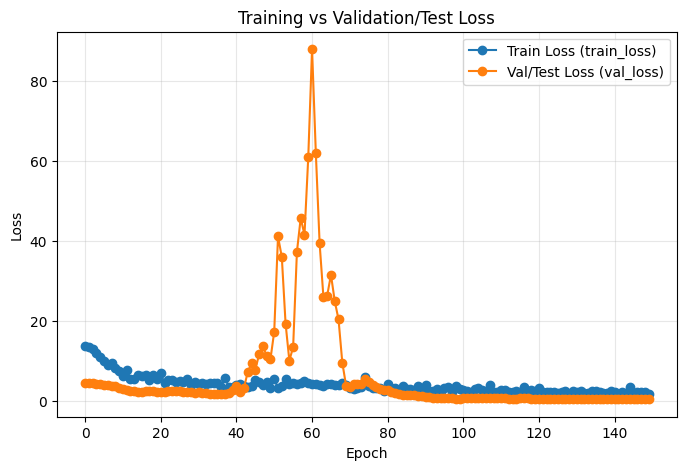

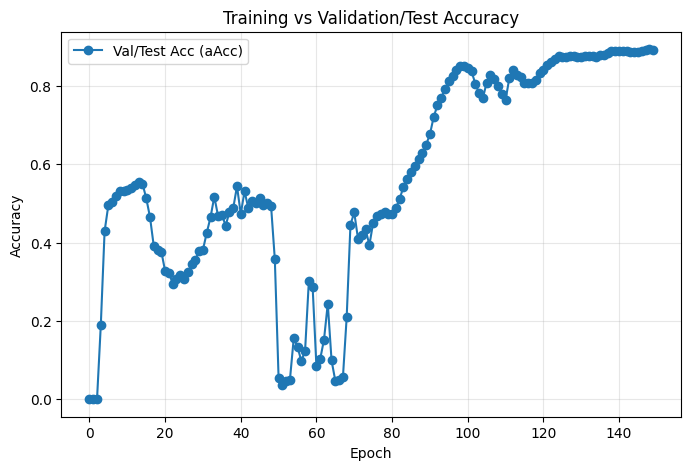


[NOTE]
Code train loop gốc của bạn không lưu train accuracy vào metrics_history,
nên nếu bạn chưa tự thêm train_acc/train_mAcc/... thì hiện tại KHÔNG thể vẽ train acc thật từ history cũ.
Cell này sẽ chỉ vẽ được val/test acc bằng key nó tìm thấy.


In [165]:
# =========================================================
# CELL — Plot loss + acc from YOUR notebook history
# Ưu tiên metric mới nếu bạn đã đổi key trong metrics_history
# =========================================================
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) Load history
# ---------------------------------------------------------
history = None

if "metrics_history" in globals() and isinstance(metrics_history, list) and len(metrics_history) > 0:
    history = metrics_history
    print("Using in-memory metrics_history")
elif "METRICS_JSON_PATH" in globals() and os.path.isfile(METRICS_JSON_PATH):
    with open(METRICS_JSON_PATH, "r", encoding="utf-8") as f:
        history = json.load(f)
    print(f"Loaded history from: {METRICS_JSON_PATH}")
else:
    raise FileNotFoundError("Không thấy metrics_history trong RAM và cũng không thấy METRICS_JSON_PATH trên disk.")

if len(history) == 0:
    raise ValueError("History rỗng, không có gì để vẽ.")

print(f"Num epochs in history: {len(history)}")
print("Available keys in first row:")
print(list(history[0].keys()))

# ---------------------------------------------------------
# 2) Helper
# ---------------------------------------------------------
def get_series(hist, key_candidates):
    for k in key_candidates:
        if all((k in row) for row in hist):
            return k, [row[k] for row in hist]
    return None, None

epochs_key, epochs = get_series(history, ["epoch"])
if epochs is None:
    epochs = list(range(len(history)))

# ---------------------------------------------------------
# 3) Loss keys
# ---------------------------------------------------------
train_loss_key, train_loss = get_series(history, [
    "train_loss",
    "loss_train",
])

val_loss_key, val_loss = get_series(history, [
    "val_loss",
    "test_loss",
    "valid_loss",
    "eval_loss",
    "loss_val",
])

# ---------------------------------------------------------
# 4) Acc keys
# Train acc: chỉ có nếu bạn đã tự thêm vào history
# Val/Test acc: ưu tiên metric mới của bạn trước
# ---------------------------------------------------------
train_acc_key, train_acc = get_series(history, [
    "train_mAcc_present",
    "train_mAcc_fg_present",
    "train_aAcc",
    "train_mAcc",
    "train_acc",
    "train_accuracy",
])

val_acc_key, val_acc = get_series(history, [
    "mAcc_present",
    "mAcc_fg_present",
    "aAcc",
    "mAcc",
    "acc",
    "accuracy",
    "val_mAcc_present",
    "val_mAcc_fg_present",
    "val_aAcc",
    "val_mAcc",
    "val_acc",
    "test_mAcc_present",
    "test_mAcc_fg_present",
    "test_aAcc",
    "test_mAcc",
    "test_acc",
])

print("-" * 80)
print("SELECTED KEYS")
print("train_loss_key:", train_loss_key)
print("val_loss_key  :", val_loss_key)
print("train_acc_key :", train_acc_key)
print("val_acc_key   :", val_acc_key)
print("-" * 80)

# ---------------------------------------------------------
# 5) Plot LOSS
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

if train_loss is not None:
    plt.plot(epochs, train_loss, marker='o', label=f"Train Loss ({train_loss_key})")

if val_loss is not None:
    plt.plot(epochs, val_loss, marker='o', label=f"Val/Test Loss ({val_loss_key})")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation/Test Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ---------------------------------------------------------
# 6) Plot ACC
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

has_any_acc = False

if train_acc is not None:
    plt.plot(epochs, train_acc, marker='o', label=f"Train Acc ({train_acc_key})")
    has_any_acc = True

if val_acc is not None:
    plt.plot(epochs, val_acc, marker='o', label=f"Val/Test Acc ({val_acc_key})")
    has_any_acc = True

if not has_any_acc:
    plt.close()
    print("Không tìm thấy key acc nào trong history để vẽ.")
else:
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation/Test Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# ---------------------------------------------------------
# 7) Honest note
# ---------------------------------------------------------
if train_acc is None:
    print("\n[NOTE]")
    print("Code train loop gốc của bạn không lưu train accuracy vào metrics_history,")
    print("nên nếu bạn chưa tự thêm train_acc/train_mAcc/... thì hiện tại KHÔNG thể vẽ train acc thật từ history cũ.")
    print("Cell này sẽ chỉ vẽ được val/test acc bằng key nó tìm thấy.")

Using in-memory metrics_history
Num history rows: 150
First row keys: ['epoch', 'train_loss', 'val_loss', 'mIoU', 'mAcc', 'aAcc', 'best_mIoU', 'global_iter', 'is_best']
Scanning checkpoint files in: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit
Found .pth files: 0
Epoch checkpoints found: 0


attach_recomputed_metrics:   0%|          | 0/150 [00:00<?, ?it/s]

Recomputed epochs: 0/150
train_acc_key: None
val_acc_key  : aAcc


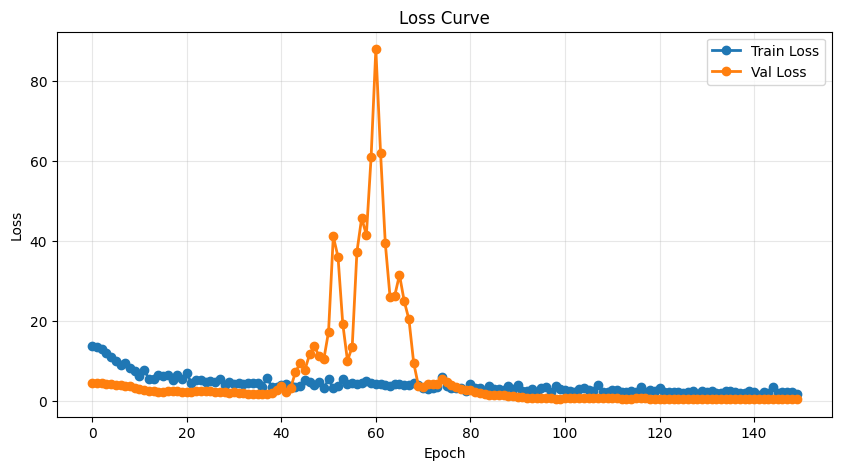

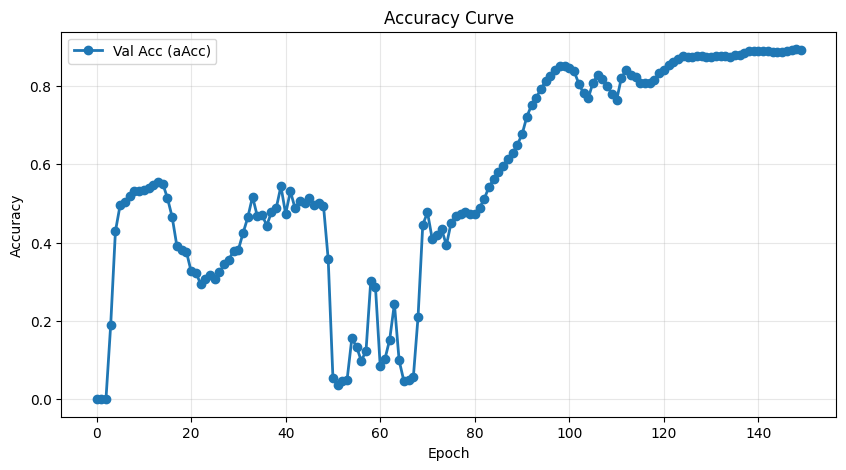

Saved recomputed history to: /content/drive/MyDrive/[PROJECT][COMPUTER-VISION]/train-fast-overfit/metrics_history_overfit8_recomputed.json
Không tìm thấy checkpoint từng epoch trong Drive => chưa recompute được metric mới theo epoch.
Biểu đồ acc đang fallback sang metric sẵn có trong history.


In [166]:
# =========================================================
# CELL — Load epoch checkpoints from Drive, recompute metrics, replot
# =========================================================
import os
import re
import gc
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

# ---------------------------------------------------------
# 1) Load metrics history
# ---------------------------------------------------------
if "metrics_history" in globals() and isinstance(metrics_history, list) and len(metrics_history) > 0:
    history = metrics_history
    print("Using in-memory metrics_history")
else:
    assert os.path.isfile(METRICS_JSON_PATH), f"Missing history file: {METRICS_JSON_PATH}"
    with open(METRICS_JSON_PATH, "r", encoding="utf-8") as f:
        history = json.load(f)
    print(f"Loaded history from: {METRICS_JSON_PATH}")

assert len(history) > 0, "History is empty"

for i, row in enumerate(history):
    if "epoch" not in row:
        row["epoch"] = i

history = sorted(history, key=lambda x: x["epoch"])
epochs = [row["epoch"] for row in history]

print(f"Num history rows: {len(history)}")
print("First row keys:", list(history[0].keys()))

# ---------------------------------------------------------
# 2) Metric mới: average theo class xuất hiện trong từng ảnh
# ---------------------------------------------------------
@torch.no_grad()
def recompute_present_metrics(model, loader, num_classes, ignore_index=255, background_id=0, device="cuda"):
    model.eval()

    total_correct = 0
    total_labeled = 0

    image_macc_present = []
    image_macc_fg_present = []
    image_miou_present = []
    image_miou_fg_present = []

    for images, masks, stems, _, _ in tqdm(loader, desc="recompute", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        for b in range(images.size(0)):
            pred = preds[b]
            gt = masks[b]

            valid = (gt != ignore_index)
            if valid.sum().item() == 0:
                continue

            pred_v = pred[valid]
            gt_v = gt[valid]

            total_correct += (pred_v == gt_v).sum().item()
            total_labeled += gt_v.numel()

            present_classes = torch.unique(gt_v)
            present_classes = present_classes[(present_classes >= 0) & (present_classes < num_classes)]

            accs = []
            accs_fg = []
            ious = []
            ious_fg = []

            for c in present_classes.tolist():
                gt_c = (gt_v == c)
                pred_c = (pred_v == c)

                inter = (gt_c & pred_c).sum().item()
                union = (gt_c | pred_c).sum().item()
                gt_cnt = gt_c.sum().item()

                acc_c = inter / gt_cnt if gt_cnt > 0 else 0.0
                iou_c = inter / union if union > 0 else 0.0

                accs.append(acc_c)
                ious.append(iou_c)

                if c != background_id:
                    accs_fg.append(acc_c)
                    ious_fg.append(iou_c)

            if len(accs) > 0:
                image_macc_present.append(float(np.mean(accs)))
            if len(accs_fg) > 0:
                image_macc_fg_present.append(float(np.mean(accs_fg)))
            if len(ious) > 0:
                image_miou_present.append(float(np.mean(ious)))
            if len(ious_fg) > 0:
                image_miou_fg_present.append(float(np.mean(ious_fg)))

    return {
        "aAcc": total_correct / max(total_labeled, 1),
        "mAcc_present": float(np.mean(image_macc_present)) if len(image_macc_present) > 0 else 0.0,
        "mAcc_fg_present": float(np.mean(image_macc_fg_present)) if len(image_macc_fg_present) > 0 else 0.0,
        "mIoU_present": float(np.mean(image_miou_present)) if len(image_miou_present) > 0 else 0.0,
        "mIoU_fg_present": float(np.mean(image_miou_fg_present)) if len(image_miou_fg_present) > 0 else 0.0,
        "num_images_used": len(image_macc_present),
    }

# ---------------------------------------------------------
# 3) Quét checkpoint từng epoch trong Drive
# ---------------------------------------------------------
save_dir = CFG["SAVE_DIR"]
print(f"Scanning checkpoint files in: {save_dir}")

all_pths = sorted(glob.glob(os.path.join(save_dir, "*.pth")))
print(f"Found .pth files: {len(all_pths)}")
for p in all_pths[:20]:
    print(" -", os.path.basename(p))

def extract_epoch_from_name(path):
    name = os.path.basename(path)

    # ví dụ: epoch_030, epoch30, ep_30, ep30
    pats = [
        r'epoch[_\-]?(\d+)',
        r'ep[_\-]?(\d+)',
    ]
    for pat in pats:
        m = re.search(pat, name, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))

    # fallback: nếu tên file có số
    nums = re.findall(r'\d+', name)
    if len(nums) > 0:
        return int(nums[-1])

    return None

epoch_to_ckpt = {}
skip_names = {CFG["LAST_CKPT"], CFG["BEST_CKPT"]}

for p in all_pths:
    base = os.path.basename(p)
    if base in skip_names:
        continue
    ep = extract_epoch_from_name(p)
    if ep is not None:
        epoch_to_ckpt[ep] = p

print(f"Epoch checkpoints found: {len(epoch_to_ckpt)}")
if len(epoch_to_ckpt) > 0:
    sample_eps = sorted(epoch_to_ckpt.keys())[:10]
    print("Sample epochs:", sample_eps)

# ---------------------------------------------------------
# 4) Recompute theo từng epoch có ckpt
# ---------------------------------------------------------
device = CFG["DEVICE"]
recomputed_count = 0

for row in tqdm(history, desc="attach_recomputed_metrics", leave=False):
    ep = row["epoch"]
    ckpt_path = epoch_to_ckpt.get(ep, None)

    if ckpt_path is None:
        continue

    ckpt = torch.load(ckpt_path, map_location=device)

    tmp_model = BiSeNetV1(n_classes=NUM_CLASSES).to(device)
    tmp_model.load_state_dict(ckpt["model"], strict=True)

    scores = recompute_present_metrics(
        model=tmp_model,
        loader=val_loader,
        num_classes=NUM_CLASSES,
        ignore_index=CFG["IGNORE_INDEX"],
        background_id=BACKGROUND_ID,
        device=device
    )

    row["re_mAcc_present"] = scores["mAcc_present"]
    row["re_mAcc_fg_present"] = scores["mAcc_fg_present"]
    row["re_mIoU_present"] = scores["mIoU_present"]
    row["re_mIoU_fg_present"] = scores["mIoU_fg_present"]
    row["re_aAcc"] = scores["aAcc"]

    recomputed_count += 1

    del tmp_model
    del ckpt
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Recomputed epochs: {recomputed_count}/{len(history)}")

# ---------------------------------------------------------
# 5) Chọn series để vẽ
# ---------------------------------------------------------
def get_series(hist, key):
    out = []
    has_any = False
    for row in hist:
        if key in row:
            out.append(row[key])
            has_any = True
        else:
            out.append(np.nan)
    return out if has_any else None

train_loss = get_series(history, "train_loss")
val_loss   = get_series(history, "val_loss")

# train acc: chỉ có nếu bạn đã từng lưu nó
train_acc = None
train_acc_key = None
for k in ["train_mAcc_present", "train_mAcc_fg_present", "train_aAcc", "train_mAcc", "train_acc"]:
    s = get_series(history, k)
    if s is not None:
        train_acc = s
        train_acc_key = k
        break

# val acc: ưu tiên metric mới recompute
val_acc = None
val_acc_key = None
for k in ["re_mAcc_present", "re_mAcc_fg_present", "re_aAcc", "mAcc_present", "mAcc_fg_present", "aAcc", "mAcc"]:
    s = get_series(history, k)
    if s is not None:
        val_acc = s
        val_acc_key = k
        break

print("train_acc_key:", train_acc_key)
print("val_acc_key  :", val_acc_key)

# ---------------------------------------------------------
# 6) Vẽ LOSS
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
if train_loss is not None:
    plt.plot(epochs, train_loss, marker='o', linewidth=2, label="Train Loss")
if val_loss is not None:
    plt.plot(epochs, val_loss, marker='o', linewidth=2, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ---------------------------------------------------------
# 7) Vẽ ACC
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
has_any = False

if train_acc is not None:
    plt.plot(epochs, train_acc, marker='o', linewidth=2, label=f"Train Acc ({train_acc_key})")
    has_any = True

if val_acc is not None:
    plt.plot(epochs, val_acc, marker='o', linewidth=2, label=f"Val Acc ({val_acc_key})")
    has_any = True

if has_any:
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    plt.close()
    print("Không có acc để vẽ.")

# ---------------------------------------------------------
# 8) Lưu history mới sau khi gắn recomputed metrics
# ---------------------------------------------------------
recomputed_json_path = os.path.join(CFG["SAVE_DIR"], "metrics_history_overfit8_recomputed.json")
with open(recomputed_json_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print(f"Saved recomputed history to: {recomputed_json_path}")
print("=" * 80)
if recomputed_count == 0:
    print("Không tìm thấy checkpoint từng epoch trong Drive => chưa recompute được metric mới theo epoch.")
    print("Biểu đồ acc đang fallback sang metric sẵn có trong history.")
elif recomputed_count < len(history):
    print("Đã recompute được một phần epoch có checkpoint.")
else:
    print("Đã recompute đầy đủ metric mới cho toàn bộ epoch.")
print("=" * 80)